In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs 
%matplotlib inline

In [2]:
# Generate a synthetic dataset with clear clusters for clustering experiments
X, y = make_blobs(
    n_samples=1000,      # create 1000 data points
    centers=3,           # generate data around 3 cluster centers (3 clusters)
    n_features=2,        # each data point has 2 features (2D data for easy plotting)
    cluster_std=0.8,     # controls how spread out each cluster is (smaller = tighter clusters)
    random_state=42     # fixes the randomness so results are the same every time we run the code
)

In [3]:
X

array([[-6.65299689, -7.08723357],
       [-6.28595089, -6.64067553],
       [ 5.08654037,  2.033974  ],
       ...,
       [ 3.88035973,  4.07907534],
       [ 4.15226907,  1.82359264],
       [-7.32936161, -7.04748709]])

In [4]:
y

array([2, 2, 1, 0, 0, 2, 1, 1, 1, 1, 0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 1, 2,
       2, 2, 1, 0, 0, 0, 1, 1, 2, 2, 1, 0, 0, 2, 2, 1, 2, 2, 0, 1, 0, 2,
       0, 2, 0, 0, 2, 1, 2, 0, 1, 2, 0, 2, 0, 0, 0, 1, 1, 0, 2, 2, 0, 0,
       2, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 0, 0, 0, 1, 0, 0, 0, 1, 2, 1, 2,
       0, 0, 0, 0, 1, 1, 2, 1, 2, 0, 1, 1, 1, 2, 2, 0, 2, 1, 1, 0, 1, 0,
       2, 1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 2, 1, 2, 2, 1, 2, 1, 1, 0, 1,
       1, 2, 0, 2, 0, 1, 1, 1, 0, 0, 2, 2, 2, 0, 1, 0, 0, 0, 0, 2, 1, 2,
       0, 1, 0, 1, 0, 2, 1, 0, 0, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 1, 0, 2,
       1, 2, 1, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 2, 1, 1,
       1, 2, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 1, 1, 0, 2, 0, 2, 1,
       2, 2, 1, 0, 2, 0, 0, 1, 2, 0, 0, 2, 0, 2, 1, 1, 2, 1, 2, 1, 2, 2,
       2, 1, 2, 0, 1, 0, 1, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 0, 2, 1,
       2, 2, 1, 0, 0, 2, 1, 0, 1, 1, 0, 2, 0, 2, 2, 1, 2, 1, 2, 1, 1, 0,
       0, 1, 0, 2, 2, 0, 1, 1, 2, 0, 1, 2, 2, 0, 2,

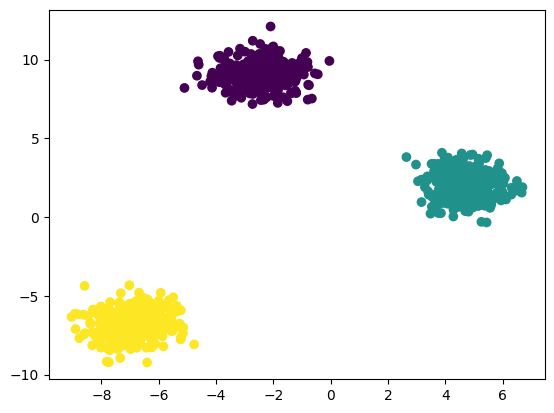

In [5]:
plt.scatter(X[:,0], X[:,1], c=y)

In [6]:
# Standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [9]:
# Fit the scaler on the training data and scale it (learn mean/std from X_train, then apply scaling)
X_train_scaled = scaler.fit_transform(X_train)

# Scale the test data using the same scaling parameters learned from the training data
# (important to avoid data leakage)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans

#### **WCSS**
WCSS is the sum of squared distances between each data point and the centroid of the cluster it belongs to. It tells us how tightly grouped the points are within each cluster.

In simple words:
- Lower WCSS → better clustering (points are closer to their cluster center).
- As the number of clusters K increases, WCSS always decreases (because clusters become smaller).

Why it’s used:
- WCSS is plotted against different values of K in the Elbow Method to find the optimal number of clusters. The “elbow point” shows where adding more clusters gives diminishing improvement.

In [11]:
# Elbow method to select the optimal number of clusters (K)

wcss = []  # list to store WCSS (within-cluster sum of squares) values for different K values

for k in range(1, 11):  # try K values from 1 to 10
    # Create a K-Means model with k clusters using k-means++ initialization
    kmeans = KMeans(n_clusters=k, init="k-means++")
    
    # Fit the K-Means model on the scaled training data
    kmeans.fit(X_train_scaled)
    
    # Store the WCSS value (inertia) for this value of K
    # Lower WCSS means clusters are more compact
    wcss.append(kmeans.inertia_)

In [12]:
wcss

[1340.0,
 413.60677231059515,
 28.202235102564117,
 24.8910978803485,
 23.44807921728195,
 18.560825302334745,
 15.14485468366998,
 14.451407361042843,
 12.67243720648401,
 12.189152731724093]

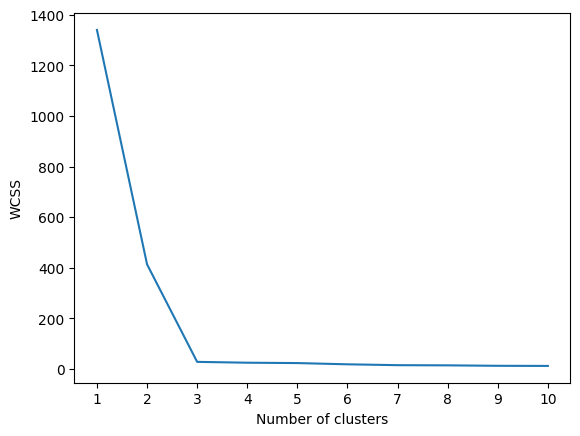

In [ ]:
# Plot the Elbow Curve to find the optimal number of clusters (K)

# Plot WCSS values against number of clusters (1 to 10)
plt.plot(range(1, 11), wcss)

# Set x-axis ticks to show each possible K value clearly
plt.xticks(range(1, 11))

plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()


In [15]:
kmeans = KMeans(n_clusters=3, init="k-means++")

In [16]:
kmeans.fit_predict(X_train, X_test_scaled)

array([2, 0, 2, 1, 0, 2, 2, 1, 2, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 2, 1,
       0, 1, 1, 2, 0, 1, 1, 0, 1, 0, 0, 0, 1, 2, 1, 2, 2, 0, 0, 0, 1, 2,
       2, 1, 2, 2, 1, 0, 0, 1, 0, 2, 0, 1, 0, 2, 1, 2, 0, 2, 2, 2, 2, 1,
       0, 0, 0, 2, 2, 0, 0, 2, 1, 1, 2, 0, 1, 2, 0, 0, 0, 0, 0, 0, 2, 1,
       1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 2, 1, 2, 1, 2, 0, 1, 1, 0, 0, 2,
       1, 0, 1, 0, 1, 0, 1, 2, 2, 1, 1, 2, 1, 2, 2, 1, 2, 1, 2, 0, 2, 2,
       1, 2, 2, 0, 1, 1, 1, 0, 0, 2, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 2, 2, 2, 2, 0, 2, 2, 2, 1, 0, 0, 0, 2, 0, 0, 2, 2, 2,
       2, 2, 1, 1, 2, 2, 1, 2, 0, 0, 2, 0, 2, 0, 2, 1, 0, 0, 1, 1, 0, 1,
       2, 2, 1, 2, 1, 2, 1, 0, 0, 0, 1, 2, 1, 1, 0, 0, 0, 2, 2, 1, 0, 2,
       0, 0, 2, 1, 0, 2, 2, 1, 1, 1, 0, 0, 2, 2, 2, 2, 0, 1, 2, 0, 1, 0,
       0, 0, 2, 1, 0, 0, 1, 0, 2, 1, 1, 0, 1, 1, 2, 2, 0, 0, 1, 0, 1, 0,
       2, 1, 2, 2, 1, 2, 1, 0, 0, 2, 1, 0, 2, 2, 0, 2, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 2, 0, 1, 1, 0, 0, 0, 0, 2, 1,

In [17]:
y_pred = kmeans.predict(X_test_scaled)

In [18]:
y_pred

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

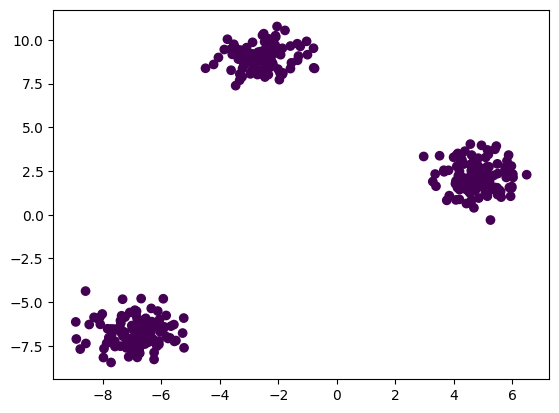

In [ ]:
# Create a scatter plot of the test data points
# X_test[:, 0] -> values of the first feature (x-axis)
# X_test[:, 1] -> values of the second feature (y-axis)
# c=y_pred     -> color each point based on the predicted cluster label

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)

### ✅ Validating the K Value in K-Means Clustering

Choosing the correct number of clusters (**K**) is an important step in K-Means. Two common methods used to validate the value of K are:

---

### 🔹 1. KneeLocator (Elbow Method Automation)

- KneeLocator is used to **automatically detect the “elbow point”** in the WCSS vs K curve.  
- The elbow point indicates the value of K after which adding more clusters gives **very little improvement**.  
- It removes the need for manual inspection of the elbow plot.

**In simple words:**  
KneeLocator finds the point where the curve bends the most, suggesting the optimal number of clusters.

---

### 🔹 2. Silhouette Scoring

- Silhouette Score measures **how well data points are grouped within their clusters** compared to other clusters.  
- The score ranges from **-1 to +1**:  
  - Values close to **+1** → well-separated clusters  
  - Values around **0** → overlapping clusters  
  - Negative values → poor clustering  
- The value of **K with the highest silhouette score** is considered the best.

**In simple words:**  
Silhouette Score helps evaluate the **quality of clustering** and choose the K that gives the most well-separated clusters.

---

### 📝 Summary  
- **KneeLocator** helps find the optimal K by detecting the elbow point automatically.  
- **Silhouette Score** helps validate how good the clusters are for different values of K.

In [ ]:
## KneeLocator

!pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from kneed import KneeLocator

In [37]:
# KneeLocator is used to automatically find the "elbow point" in the WCSS curve
# range(1, 11) -> list of K values (number of clusters tested from 1 to 10)
# wcss        -> WCSS values corresponding to each K
# curve="convex" -> specifies the shape of the elbow curve (typical for WCSS vs K)
# direction="decreasing" -> WCSS decreases as K increases

k1 = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")

In [38]:
# k1.elbow returns the optimal number of clusters (K)
# It gives the K value at which the "elbow point" is detected in the WCSS curve
# This is the point where adding more clusters does not significantly improve clustering

k1.elbow

3

In [25]:
## silhoutte score

from sklearn.metrics import silhouette_score

In [ ]:
# Create an empty list to store silhouette scores for different values of K
silhouette_coefficients = []

# Try different numbers of clusters from 2 to 10
# (Silhouette score is not defined for k = 1, so we start from 2)
for k in range(2, 11):
    
    # Create a K-Means model with k clusters
    # k-means++ helps in better initialization of centroids
    kmeans = KMeans(n_clusters=k, init="k-means++")
    
    # Fit the K-Means model on the scaled training data
    kmeans.fit(X_train_scaled)
    
    # Compute the silhouette score for the current value of K
    # This measures how well the data points are clustered
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    
    # Store the silhouette score
    silhouette_coefficients.append(score)

In [40]:
# silhouette_coefficients is a list that stores silhouette scores
# Each value in this list corresponds to a particular number of clusters (K)
# For example:
# silhouette_coefficients[0] -> silhouette score for k = 2
# silhouette_coefficients[1] -> silhouette score for k = 3
# ...
# Higher silhouette score means better clustering quality

silhouette_coefficients

[0.7021398282847465,
 0.8741111121159924,
 0.6977003085243216,
 0.5308333070158767,
 0.5078597038910111,
 0.3467105964251608,
 0.34379838642070737,
 0.3331685447423745,
 0.3380488981846719]

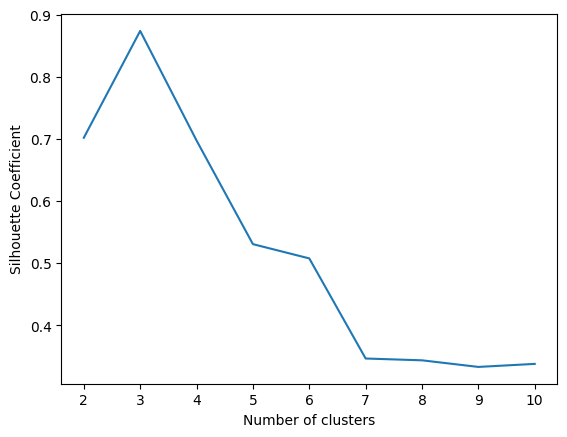

In [41]:
# Plot the Silhouette Scores to help find the optimal number of clusters (K)

# Plot silhouette coefficient values against number of clusters (from 2 to 10)
plt.plot(range(2, 11), silhouette_coefficients)

# Set x-axis ticks to show each K value clearly
plt.xticks(range(2, 11))

# Label the x-axis as Number of clusters (K)
plt.xlabel("Number of clusters")

# Label the y-axis as Silhouette Coefficient
plt.ylabel("Silhouette Coefficient")

# Display the plot
plt.show()